In [3]:
import pandas as pd
import matplotlib.pyplot as plt

utilities = pd.read_csv('data-science/utilities_clean.csv')
substations = pd.read_csv('data-science/substations_clean.csv')
lines = pd.read_csv('data-science/lines_clean.csv')

print("Utilities:", utilities.shape)
print("Substations:", substations.shape)
print("Lines:", lines.shape)

Utilities: (10, 7)
Substations: (44, 12)
Lines: (55, 11)


In [7]:
# Fix truncated country names found during EDA
print("Before fix:")
print(substations['Country'].value_counts())

substations['Country'] = substations['Country'].replace({
    'Burkina': 'Burkina Faso',
    'Cote': "Cote d'Ivoire"
})

print("\nAfter fix:")
print(substations['Country'].value_counts())

Before fix:
Country
Ghana      36
Burkina     2
Cote        2
Togo        2
Benin       1
Guinea      1
Name: count, dtype: int64

After fix:
Country
Ghana            36
Burkina Faso      2
Cote d'Ivoire     2
Togo              2
Benin             1
Guinea            1
Name: count, dtype: int64


In [28]:
pd.set_option('display.max_rows', None)

print(" Utilities: Type counts ")
print(utilities['Type'].value_counts())

print("\nSubstations: Region counts ")
print(substations['Region'].value_counts())



 Utilities: Type counts 
Type
Distribution    6
Transmission    2
Generation      2
Name: count, dtype: int64

Substations: Region counts 
Region
Greater Accra           6
Ashanti                 5
Western                 4
Central                 4
Eastern                 4
Volta                   4
Bono                    3
Northern                3
Upper East              2
Upper West              1
Burkina Faso border     1
Cote d'Ivoire border    1
Togo border             1
Togo                    1
Benin                   1
Cote d'Ivoire           1
Burkina Faso            1
Guinea                  1
Name: count, dtype: int64


In [26]:
print("\n--- Substations: Country counts ---")
print(substations['Country'].value_counts())

print("\n--- Substations: Voltage level counts ---")
print(substations['Voltage (kV)'].value_counts().sort_index())

print("\n--- Substations: Status counts ---")
print(substations['Status'].value_counts())




--- Substations: Country counts ---
Country
Ghana            36
Burkina Faso      2
Cote d'Ivoire     2
Togo              2
Benin             1
Guinea            1
Name: count, dtype: int64

--- Substations: Voltage level counts ---
Voltage (kV)
11      9
33      6
69      8
161    11
330    10
Name: count, dtype: int64

--- Substations: Status counts ---
Status
Active      43
Inactive     1
Name: count, dtype: int64


In [27]:
print("\n Lines: Status counts ")
print(lines['Status'].value_counts())



print("\n Lines: Line Type counts ")
print(lines['Line Type'].value_counts())





 Lines: Status counts 
Status
Active               53
Under Maintenance     2
Name: count, dtype: int64

 Lines: Line Type counts 
Line Type
Overhead       40
Underground    15
Name: count, dtype: int64


In [29]:
print(" Substations: Numeric summary ")
print(substations[['Latitude', 'Longitude', 'Voltage (kV)', 'Capacity (MVA)']].describe())

print("\n Lines: Numeric summary ")
print(lines[['Length (km)', 'Capacity (MVA)']].describe())

 Substations: Numeric summary 
        Latitude  Longitude  Voltage (kV)  Capacity (MVA)
count  44.000000  44.000000     44.000000       44.000000
mean    6.898402  -1.194868    134.545455      157.865909
std     1.879404   2.314917    120.399810      139.923148
min     4.874700 -13.580000     11.000000        6.400000
25%     5.586350  -1.760000     33.000000       43.825000
50%     6.184400  -0.800700     69.000000      108.550000
75%     7.364200  -0.170900    161.000000      254.350000
max    11.200000   2.430000    330.000000      487.600000

 Lines: Numeric summary 
       Length (km)  Capacity (MVA)
count    55.000000       55.000000
mean     99.312727      222.400000
std      90.275104      109.181765
min       3.800000       32.900000
25%      42.900000      134.550000
50%      75.900000      229.900000
75%     129.600000      292.100000
max     426.000000      506.300000


In [30]:
print(" Top 10 Substations by Number of Lines ")
print(lines['Source Substation'].value_counts().head(10))

 Top 10 Substations by Number of Lines 
Source Substation
Achimota Substation          4
Cape Coast Substation        4
Mallam Substation            3
Kumasi Central Substation    3
Takoradi Substation          3
Koforidua Substation         3
Ho Substation                3
Bolgatanga Substation        3
Tema Substation              2
Legon Substation             2
Name: count, dtype: int64


In [31]:
lines_with_utility = lines.merge(utilities[['Utility ID', 'Name', 'Alias']], on='Utility ID', how='left')

print(" Top Utilities by Number of Lines Operated ")
print(lines_with_utility['Alias'].value_counts())

 Top Utilities by Number of Lines Operated 
Alias
GRIDCo     24
NEDCo      14
ECG        10
CEB         3
SONABEL     2
CIE         2
Name: count, dtype: int64


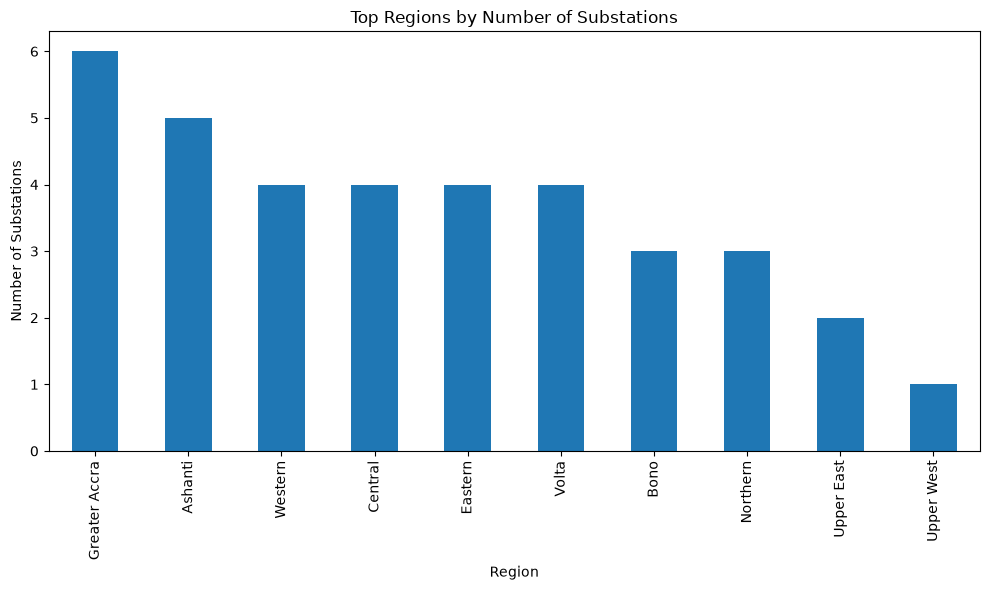

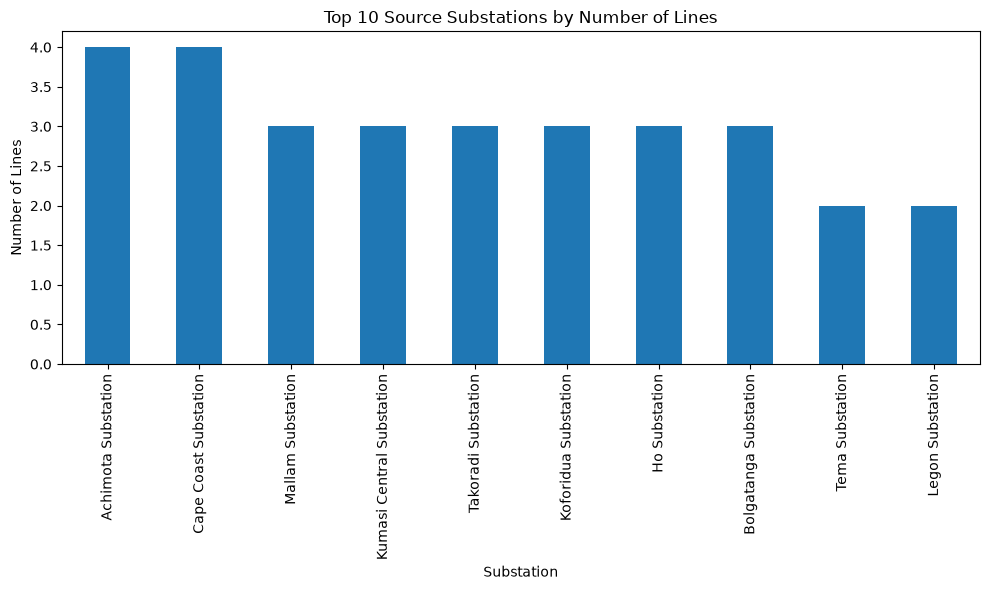

In [ ]:
# Substations: distribution by region
plt.figure(figsize=(10, 6))
substations['Region'].value_counts().head(10).plot(kind='bar', title='Top Regions by Number of Substations')
plt.xlabel('Region')
plt.ylabel('Number of Substations')
plt.tight_layout()
plt.savefig('eda_regions.png')
plt.show()



# Lines: top 10 source substations
plt.figure(figsize=(10, 6))
lines['Source Substation'].value_counts().head(10).plot(kind='bar', title='Top 10 Source Substations by Number of Lines')
plt.xlabel('Substation')
plt.ylabel('Number of Lines')
plt.tight_layout()
plt.savefig('eda_top_substations.png')
plt.show()

EDA Patterns and Findings

1. Greater Accra has 6 substations making it the most urbanized and economically active region in Ghana. Cross border regions have fewer substations

2. GRIDCo operates by far the most lines, consistent with its role as Ghana's national transmission utility.

3. Achimota and Cape Coast are among the most connected substations by number of lines

4. Substations span the full hierarchy of the grid, from 11kV local distribution up to 330kV transmission/cross-border lines, with a median around 69kV.

---Hypothesis About Network Structure---

1. GRIDCo's dominance in line count suggests the network's backbone connectivity depends heavily on a single utility.

2. Highly-connected substations (e.g. Achimota) may act as structural hubs whose removal could disproportionately fragment the network 

3. Higher-voltage lines likely correlate with longer distances, since long-distance transmission requires higher voltage to limit power loss.
